In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/final_project/"
print("Imports done ✅")

Mounted at /content/drive
Imports done ✅


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

# Load bank clean data
df = pd.read_csv(SAVE_PATH + "bank_clean.csv")

# Load Phase 3 behavioral scores
behavioral_scores = np.load(
    SAVE_PATH + "behavioral_scores.npy"
)

print(f"Bank data shape      : {df.shape}")
print(f"Behavioral scores    : {behavioral_scores.shape}")
print(f"\nSample behavioral scores:")
print(np.round(behavioral_scores[:5], 4))
print(f"\nColumns in bank data:")
print(df.columns.tolist())

Bank data shape      : (41188, 20)
Behavioral scores    : (41188,)

Sample behavioral scores:
[0.1631 0.1533 0.1703 0.1638 0.1767]

Columns in bank data:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
# Phase 2 CNN works on live audio
# For batch segmentation we simulate
# sentiment from behavioral call features

df_work = df.copy()

# Encode poutcome for sentiment signal
df_work['poutcome_success'] = (
    df_work['poutcome'] == 'success'
).astype(int)

df_work['poutcome_failure'] = (
    df_work['poutcome'] == 'failure'
).astype(int)

# Normalize key features
scaler_sim = MinMaxScaler()

sim_features = df_work[[
    'previous',          # previous contacts → engaged
    'poutcome_success',  # past success → positive
    'campaign',          # current contacts → negative
    'poutcome_failure',  # past failure → negative
    'pdays'              # days since contact → neutral
]].copy()

# Handle pdays = 999 (never contacted)
sim_features['pdays'] = sim_features['pdays'].replace(
    999, sim_features['pdays'][
        sim_features['pdays'] != 999
    ].max()
)

sim_scaled = scaler_sim.fit_transform(sim_features)

# Weighted sentiment formula
sentiment_raw = (
    + 0.35 * sim_scaled[:, 0]   # previous → positive
    + 0.30 * sim_scaled[:, 1]   # success  → positive
    - 0.20 * sim_scaled[:, 2]   # campaign → negative
    - 0.10 * sim_scaled[:, 3]   # failure  → negative
    - 0.05 * sim_scaled[:, 4]   # pdays    → negative
)

# Add realistic noise
np.random.seed(42)
noise = np.random.normal(0, 0.05, sentiment_raw.shape)
sentiment_raw = sentiment_raw + noise

# Scale to 0-1
sentiment_score = MinMaxScaler().fit_transform(
    sentiment_raw.reshape(-1, 1)
).flatten()

print(f"Sentiment score range : "
      f"{sentiment_score.min():.3f} → "
      f"{sentiment_score.max():.3f}")
print(f"Mean sentiment        : "
      f"{sentiment_score.mean():.3f}")
print(f"\nDistribution:")
print(f"  Positive (>0.5) : "
      f"{(sentiment_score > 0.5).sum()} "
      f"({(sentiment_score > 0.5).mean()*100:.1f}%)")
print(f"  Negative (<0.5) : "
      f"{(sentiment_score < 0.5).sum()} "
      f"({(sentiment_score < 0.5).mean()*100:.1f}%)")

Sentiment score range : 0.000 → 1.000
Mean sentiment        : 0.267

Distribution:
  Positive (>0.5) : 1369 (3.3%)
  Negative (<0.5) : 39819 (96.7%)


In [ ]:
# Select key behavioral features
segment_features = df_work[[
    'age',
    'campaign',
    'previous',
    'pdays',
    'emp.var.rate',
    'cons.conf.idx',
    'cons.price.idx',
    'euribor3m',
    'nr.employed'
]].copy()

# Handle pdays = 999
segment_features['pdays'] = segment_features[
    'pdays'
].replace(999, segment_features['pdays'][
    segment_features['pdays'] != 999
].max())

# Add Phase 2 sentiment score
segment_features['sentiment_score'] = sentiment_score

# Add Phase 3 behavioral score
segment_features['behavioral_score'] = behavioral_scores

print(f"Segmentation features shape: "
      f"{segment_features.shape}")
print(f"\nFeatures used:")
for col in segment_features.columns:
    print(f"  {col}")

Segmentation features shape: (41188, 11)

Features used:
  age
  campaign
  previous
  pdays
  emp.var.rate
  cons.conf.idx
  cons.price.idx
  euribor3m
  nr.employed
  sentiment_score
  behavioral_score


In [ ]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(segment_features)

print(f"Scaled shape : {X_cluster.shape}")
print(f"Mean         : {X_cluster.mean():.6f}")
print(f"Std          : {X_cluster.std():.6f}")
print("Scaling done ✅")

Scaled shape : (41188, 11)
Mean         : -0.000000
Std          : 1.000000
Scaling done ✅


Testing K values...
  K=2 → Inertia: 286188, Silhouette: 0.4536
  K=3 → Inertia: 208669, Silhouette: 0.4693
  K=4 → Inertia: 182747, Silhouette: 0.4521
  K=5 → Inertia: 160364, Silhouette: 0.4409
  K=6 → Inertia: 145453, Silhouette: 0.2597
  K=7 → Inertia: 135185, Silhouette: 0.2441
  K=8 → Inertia: 126715, Silhouette: 0.2627
  K=9 → Inertia: 119363, Silhouette: 0.2930
  K=10 → Inertia: 110411, Silhouette: 0.2836


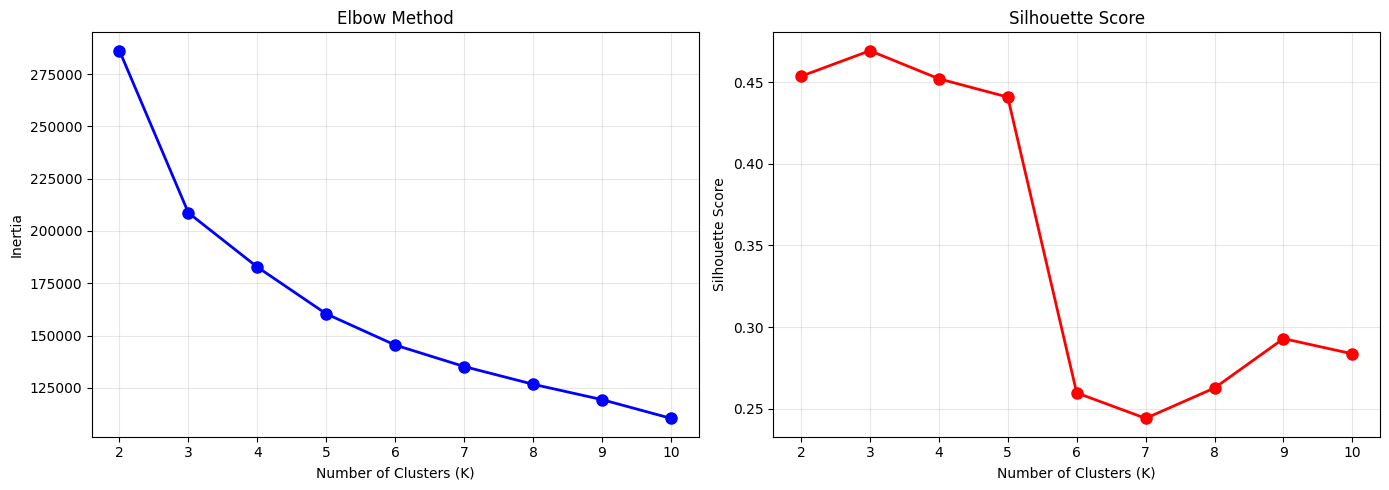


Best K by Silhouette : 3
Best Silhouette Score: 0.4693


In [ ]:
inertias   = []
sil_scores = []
K_range    = range(2, 11)

print("Testing K values...")
for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(
        X_cluster, km.labels_,
        sample_size=5000,
        random_state=42
    )
    sil_scores.append(sil)
    print(f"  K={k} → Inertia: {km.inertia_:.0f}, "
          f"Silhouette: {sil:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-',
         linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, 'ro-',
         linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette : {best_k}")
print(f"Best Silhouette Score: {max(sil_scores):.4f}")

In [ ]:
FINAL_K = 5  # business driven

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10,
    max_iter=300
)

kmeans.fit(X_cluster)
segment_features['cluster'] = kmeans.labels_

print(f"K-Means trained K={FINAL_K} ✅")
print(f"\nCluster distribution:")
print(segment_features['cluster']\
      .value_counts().sort_index())

K-Means trained K=5 ✅

Cluster distribution:
cluster
0    26086
1     1506
2     1572
3     8589
4     3435
Name: count, dtype: int64


In [ ]:
# Analyze clusters by sentiment + behavioral
cluster_summary = segment_features.groupby(
    'cluster'
).agg(
    sentiment_mean  = ('sentiment_score',  'mean'),
    behavioral_mean = ('behavioral_score', 'mean'),
    age_mean        = ('age',              'mean'),
    campaign_mean   = ('campaign',         'mean'),
    count           = ('sentiment_score',  'count')
).round(3)

# Rank by behavioral score
cluster_summary['behavioral_rank'] = \
    cluster_summary['behavioral_mean']\
    .rank(ascending=False)

print("Cluster Analysis:")
print(cluster_summary)

# Assign business labels by behavioral rank
label_map = {
    1: '🟢 Hot Lead',
    2: '🟡 Warm Lead',
    3: '🔵 Neutral',
    4: '🔴 Cold',
    5: '🔕 Do Not Disturb'
}

cluster_to_label = {}
for cluster_id, row in cluster_summary.iterrows():
    rank = int(row['behavioral_rank'])
    cluster_to_label[cluster_id] = label_map[rank]

print(f"\nCluster → Segment Mapping:")
for cluster, label in cluster_to_label.items():
    print(f"  Cluster {cluster} → {label}")

segment_features['segment'] = \
    segment_features['cluster'].map(cluster_to_label)

Cluster Analysis:
         sentiment_mean  behavioral_mean  age_mean  campaign_mean  count  \
cluster                                                                    
0                 0.258            0.273    40.177          2.202  26086   
1                 0.635            0.874    41.888          1.812   1506   
2                 0.222            0.186    40.508         12.854   1572   
3                 0.246            0.447    38.047          2.216   8589   
4                 0.251            0.770    42.769          1.847   3435   

         behavioral_rank  
cluster                   
0                    4.0  
1                    1.0  
2                    5.0  
3                    3.0  
4                    2.0  

Cluster → Segment Mapping:
  Cluster 0 → 🔴 Cold
  Cluster 1 → 🟢 Hot Lead
  Cluster 2 → 🔕 Do Not Disturb
  Cluster 3 → 🔵 Neutral
  Cluster 4 → 🟡 Warm Lead


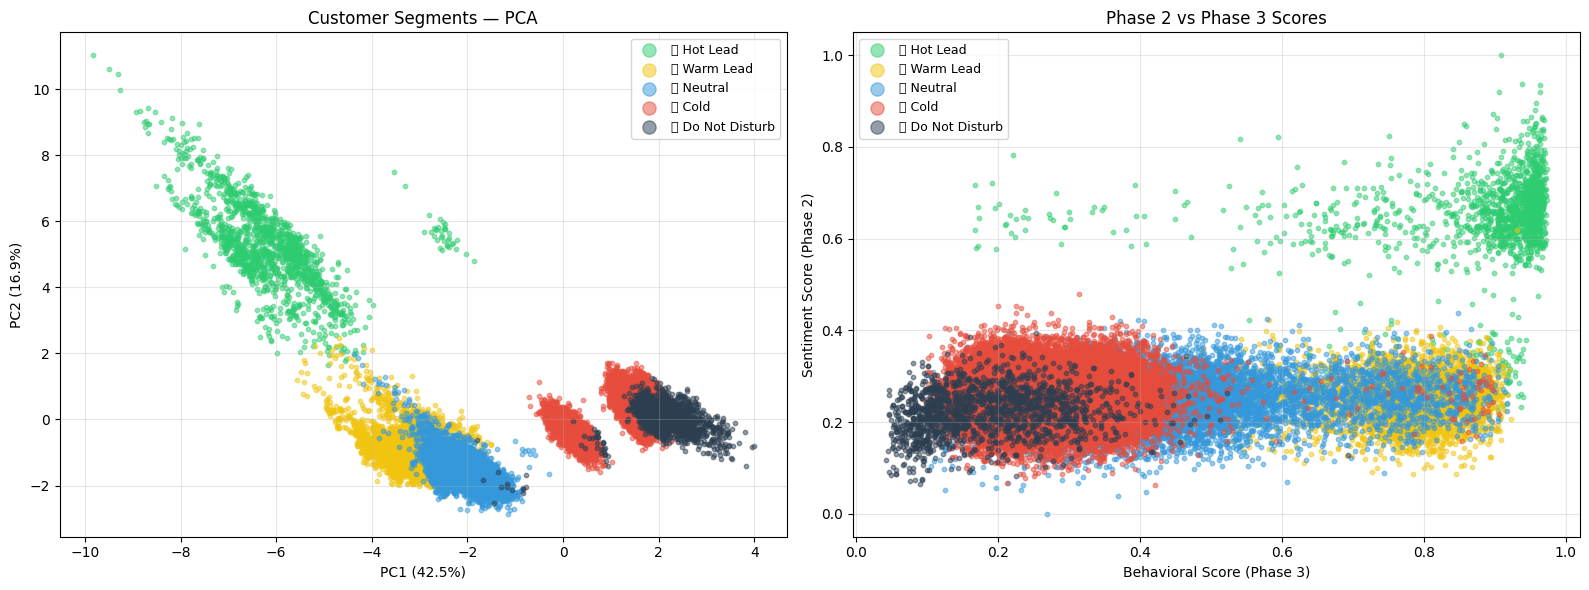

In [ ]:
colors = {
    '🟢 Hot Lead'       : '#2ecc71',
    '🟡 Warm Lead'      : '#f1c40f',
    '🔵 Neutral'        : '#3498db',
    '🔴 Cold'           : '#e74c3c',
    '🔕 Do Not Disturb' : '#2c3e50'
}

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

segment_features['pca1'] = X_pca[:, 0]
segment_features['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for segment, color in colors.items():
    if segment in segment_features['segment'].values:
        mask = segment_features['segment'] == segment
        axes[0].scatter(
            segment_features.loc[mask, 'pca1'],
            segment_features.loc[mask, 'pca2'],
            c=color, label=segment,
            alpha=0.5, s=10
        )

axes[0].set_title('Customer Segments — PCA')
axes[0].set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
)
axes[0].set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
)
axes[0].legend(markerscale=3, fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sentiment vs Behavioral
for segment, color in colors.items():
    if segment in segment_features['segment'].values:
        mask = segment_features['segment'] == segment
        axes[1].scatter(
            segment_features.loc[mask, 'behavioral_score'],
            segment_features.loc[mask, 'sentiment_score'],
            c=color, label=segment,
            alpha=0.5, s=10
        )

axes[1].set_title('Phase 2 vs Phase 3 Scores')
axes[1].set_xlabel('Behavioral Score (Phase 3)')
axes[1].set_ylabel('Sentiment Score (Phase 2)')
axes[1].legend(markerscale=3, fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PHASE 4 — CUSTOMER SEGMENTATION SUMMARY
                  count  sentiment_avg  behavioral_avg  age_avg  campaign_avg  percentage
segment                                                                                  
🔕 Do Not Disturb   1572          0.222           0.186   40.508        12.854         3.8
🔴 Cold            26086          0.258           0.273   40.177         2.202        63.3
🔵 Neutral          8589          0.246           0.447   38.047         2.216        20.9
🟡 Warm Lead        3435          0.251           0.770   42.769         1.847         8.3
🟢 Hot Lead         1506          0.635           0.874   41.888         1.812         3.7


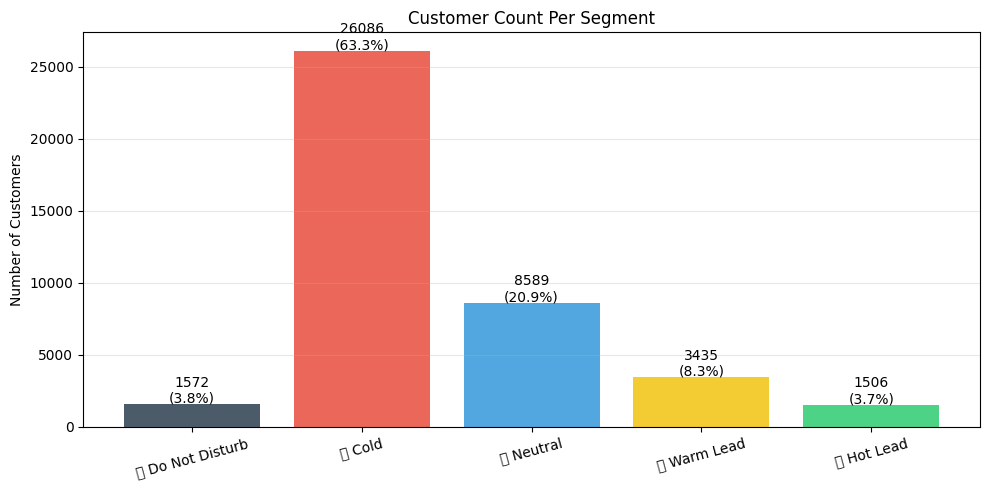

In [ ]:
final_summary = segment_features.groupby(
    'segment'
).agg(
    count          = ('sentiment_score',  'count'),
    sentiment_avg  = ('sentiment_score',  'mean'),
    behavioral_avg = ('behavioral_score', 'mean'),
    age_avg        = ('age',              'mean'),
    campaign_avg   = ('campaign',         'mean')
).round(3)

final_summary['percentage'] = (
    final_summary['count'] /
    len(segment_features) * 100
).round(1)

print("=" * 60)
print("PHASE 4 — CUSTOMER SEGMENTATION SUMMARY")
print("=" * 60)
print(final_summary.to_string())

# Bar chart
plt.figure(figsize=(10, 5))
segments = final_summary.index.tolist()
counts   = final_summary['count'].tolist()
clrs     = [colors.get(s, '#95a5a6')
            for s in segments]

bars = plt.bar(
    segments, counts,
    color=clrs, alpha=0.85
)
plt.title('Customer Count Per Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')

for bar, count, pct in zip(
        bars, counts,
        final_summary['percentage'].tolist()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{count}\n({pct}%)',
        ha='center', fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

# Add segment to main df
df['segment']          = segment_features['segment'].values
df['sentiment_score']  = sentiment_score
df['behavioral_score'] = behavioral_scores
df['cluster']          = segment_features['cluster'].values

# Save segmented data
df.to_csv(
    SAVE_PATH + "customer_segments.csv",
    index=False
)

# Save models
joblib.dump(
    kmeans,
    SAVE_PATH + "kmeans_model.pkl"
)
joblib.dump(
    scaler,
    SAVE_PATH + "segment_scaler.pkl"
)

# Save cluster mapping
with open(
    SAVE_PATH + "cluster_mapping.json", "w"
) as f:
    json.dump(
        {str(k): v for k, v in
         cluster_to_label.items()}, f
    )

# Save scores for Phase 5
np.save(
    SAVE_PATH + "sentiment_scores.npy",
    sentiment_score
)

print("All Phase 4 files saved ✅")
print(f"\nSaved:")
print("  customer_segments.csv")
print("  kmeans_model.pkl")
print("  segment_scaler.pkl")
print("  cluster_mapping.json")
print("  sentiment_scores.npy")

All Phase 4 files saved ✅

Saved:
  customer_segments.csv
  kmeans_model.pkl
  segment_scaler.pkl
  cluster_mapping.json
  sentiment_scores.npy
